In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [2]:
mc_signal = pd.read_pickle('mc_data.pkl')
mc_signal_preselection = pd.read_pickle('mc_data_all.pkl')
mc_signal_BDT = pd.read_pickle('mc_data_BDT.pkl')
mc_signal_AP = pd.read_pickle('AP_filter_mc_data.pkl')
mc_signal_candidates = pd.read_pickle('mc_data_candidates.pkl')

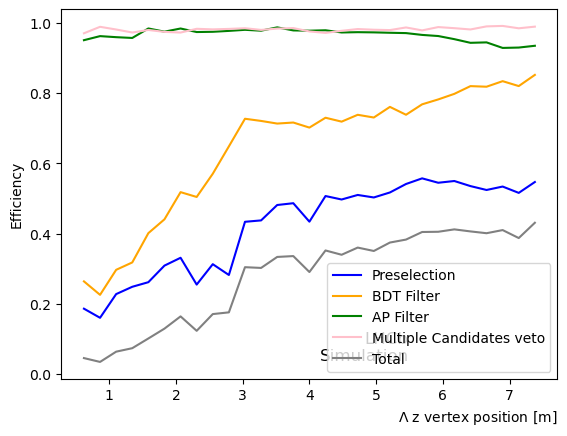

In [3]:
import numpy as np
import matplotlib.pyplot as plt


fig, ax = plt.subplots()

# Variable y bins
variable = 'p_TRUEORIGIN_VZ'
bins = np.linspace(500, 7500, 30)
bin_centres = 0.5 * (bins[1:] + bins[:-1])/1000

# Calcular histogramas
numerator_hist1, _ = np.histogram(mc_signal_preselection[variable], bins)
denominator_hist1, _ = np.histogram(mc_signal[variable], bins)

numerator_hist2, _ = np.histogram(mc_signal_BDT[variable], bins)
denominator_hist2, _ = np.histogram(mc_signal_preselection[variable], bins)

numerator_hist3, _ = np.histogram(mc_signal_AP[variable], bins)
denominator_hist3, _ = np.histogram(mc_signal_BDT[variable], bins)

numerator_hist4, _ = np.histogram(mc_signal_candidates[variable], bins)
denominator_hist4, _ = np.histogram(mc_signal_AP[variable], bins)

numerator_hist5, _ = np.histogram(mc_signal_candidates[variable], bins)
denominator_hist5, _ = np.histogram(mc_signal[variable], bins)

# Evitar división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio1 = np.divide(numerator_hist1, denominator_hist1, where=denominator_hist1 != 0)
    ratio1_errors = np.sqrt((np.sqrt(numerator_hist1) / numerator_hist1) ** 2 + (np.sqrt(denominator_hist1) / denominator_hist1) ** 2)
    ratio1[denominator_hist1 == 0] = 0
    ratio1_errors[denominator_hist1 == 0] = 0

    ratio2 = np.divide(numerator_hist2, denominator_hist2, where=denominator_hist2 != 0)
    ratio2_errors = np.sqrt((np.sqrt(numerator_hist2) / numerator_hist2) ** 2 + (np.sqrt(denominator_hist2) / denominator_hist2) ** 2)
    ratio2[denominator_hist2 == 0] = 0
    ratio2_errors[denominator_hist2 == 0] = 0

    ratio3 = np.divide(numerator_hist3, denominator_hist3, where=denominator_hist3 != 0)
    ratio3_errors = np.sqrt((np.sqrt(numerator_hist3) / numerator_hist3) ** 2 + (np.sqrt(denominator_hist3) / denominator_hist3) ** 2)
    ratio3[denominator_hist3 == 0] = 0
    ratio3_errors[denominator_hist3 == 0] = 0

    ratio4 = np.divide(numerator_hist4, denominator_hist4, where=denominator_hist4 != 0)
    ratio4_errors = np.sqrt((np.sqrt(numerator_hist4) / numerator_hist4) ** 2 + (np.sqrt(denominator_hist4) / denominator_hist4) ** 2)
    ratio4[denominator_hist4 == 0] = 0
    ratio4_errors[denominator_hist4 == 0] = 0

    ratio5 = np.divide(numerator_hist5, denominator_hist5, where=denominator_hist5 != 0)
    ratio5_errors = np.sqrt((np.sqrt(numerator_hist5) / numerator_hist5) ** 2 + (np.sqrt(denominator_hist5) / denominator_hist5) ** 2)
    ratio5[denominator_hist5 == 0] = 0
    ratio5_errors[denominator_hist5 == 0] = 0

# Graficar líneas
ax.plot(bin_centres, ratio1, label="Preselection", color='blue')
ax.plot(bin_centres, ratio2, label="BDT Filter", color='orange')
ax.plot(bin_centres, ratio3, label="AP Filter", color='green')
ax.plot(bin_centres, ratio4, label="Multiple Candidates veto", color='pink')
ax.plot(bin_centres, ratio5, label="Total", color='grey')

# Añadir texto personalizado
ax.text(0.7, 0.05, "LHCb\nSimulation", transform=ax.transAxes, fontsize=12, color='black', ha='right')

# Ajustes del gráfico
ax.legend(fontsize=10)
ax.set_xlabel(r'$\Lambda$ z vertex position [m]', fontsize=10, loc='right')
ax.set_ylabel('Efficiency')
ax.tick_params(axis='both', which='major', labelsize=10)

# Mostrar el gráfico
plt.show()


In [4]:
print(np.mean(ratio1))
print(np.mean(ratio2))
print(np.mean(ratio3))
print(np.mean(ratio4))
print(np.mean(ratio5))

0.42156680624895887
0.6438668505843385
0.9656176400107811
0.9814571040488005
0.2779288101242249


findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

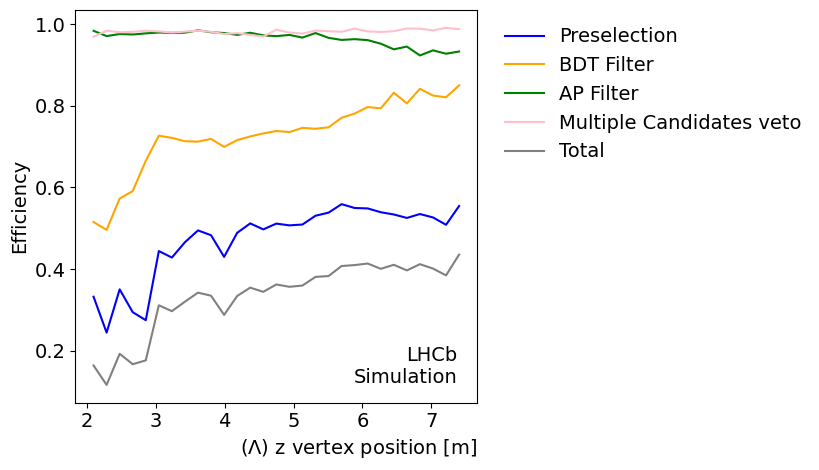

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Crear el gráfico
fig, ax = plt.subplots()

# Definir la variable y los bins
variable = 'p_TRUEORIGIN_VZ'
bins = np.linspace(2000, 7500, 30)
bin_centres = 0.5 * (bins[1:] + bins[:-1]) / 1000  # Convertir a metros

# Calcular histogramas
numerator_hist1, _ = np.histogram(mc_signal_preselection[variable], bins)
denominator_hist1, _ = np.histogram(mc_signal[variable], bins)

numerator_hist2, _ = np.histogram(mc_signal_BDT[variable], bins)
denominator_hist2, _ = np.histogram(mc_signal_preselection[variable], bins)

numerator_hist3, _ = np.histogram(mc_signal_AP[variable], bins)
denominator_hist3, _ = np.histogram(mc_signal_BDT[variable], bins)

numerator_hist4, _ = np.histogram(mc_signal_candidates[variable], bins)
denominator_hist4, _ = np.histogram(mc_signal_AP[variable], bins)

numerator_hist5, _ = np.histogram(mc_signal_candidates[variable], bins)
denominator_hist5, _ = np.histogram(mc_signal[variable], bins)

# Evitar división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio1 = np.divide(numerator_hist1, denominator_hist1, where=denominator_hist1 != 0)
    ratio1_errors = np.sqrt((np.sqrt(numerator_hist1) / numerator_hist1) ** 2 + (np.sqrt(denominator_hist1) / denominator_hist1) ** 2)
    ratio1[denominator_hist1 == 0] = 0
    ratio1_errors[denominator_hist1 == 0] = 0

    ratio2 = np.divide(numerator_hist2, denominator_hist2, where=denominator_hist2 != 0)
    ratio2_errors = np.sqrt((np.sqrt(numerator_hist2) / numerator_hist2) ** 2 + (np.sqrt(denominator_hist2) / denominator_hist2) ** 2)
    ratio2[denominator_hist2 == 0] = 0
    ratio2_errors[denominator_hist2 == 0] = 0

    ratio3 = np.divide(numerator_hist3, denominator_hist3, where=denominator_hist3 != 0)
    ratio3_errors = np.sqrt((np.sqrt(numerator_hist3) / numerator_hist3) ** 2 + (np.sqrt(denominator_hist3) / denominator_hist3) ** 2)
    ratio3[denominator_hist3 == 0] = 0
    ratio3_errors[denominator_hist3 == 0] = 0

    ratio4 = np.divide(numerator_hist4, denominator_hist4, where=denominator_hist4 != 0)
    ratio4_errors = np.sqrt((np.sqrt(numerator_hist4) / numerator_hist4) ** 2 + (np.sqrt(denominator_hist4) / denominator_hist4) ** 2)
    ratio4[denominator_hist4 == 0] = 0
    ratio4_errors[denominator_hist4 == 0] = 0

    ratio5 = np.divide(numerator_hist5, denominator_hist5, where=denominator_hist5 != 0)
    ratio5_errors = np.sqrt((np.sqrt(numerator_hist5) / numerator_hist5) ** 2 + (np.sqrt(denominator_hist5) / denominator_hist5) ** 2)
    ratio5[denominator_hist5 == 0] = 0
    ratio5_errors[denominator_hist5 == 0] = 0

# Graficar líneas
ax.plot(bin_centres, ratio1, label="Preselection", color='blue')
ax.plot(bin_centres, ratio2, label="BDT Filter", color='orange')
ax.plot(bin_centres, ratio3, label="AP Filter", color='green')
ax.plot(bin_centres, ratio4, label="Multiple Candidates veto", color='pink')
ax.plot(bin_centres, ratio5, label="Total", color='grey')

# Añadir texto personalizado
ax.text(0.95, 0.05, "LHCb\nSimulation", transform=ax.transAxes, fontsize=14, color='black', ha='right')

# Ajustes del gráfico
ax.set_xlabel(r'($\Lambda$) z vertex position [m]', fontsize=14, fontname='Times New Roman', loc='right')
ax.set_ylabel('Efficiency', fontsize=14, fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=14)

# Cambiar la fuente predeterminada a Times New Roman para todo el gráfico
plt.rcParams['font.family'] = 'Times New Roman'

# Colocar la leyenda fuera a la derecha del gráfico
legend = ax.legend(fontsize=14, bbox_to_anchor=(1.025, 1), loc='upper left')
legend.get_frame().set_linewidth(0)

# Ajustar el tamaño de la figura para hacer espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1.3, 1])

# Mostrar el gráfico
plt.show()


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

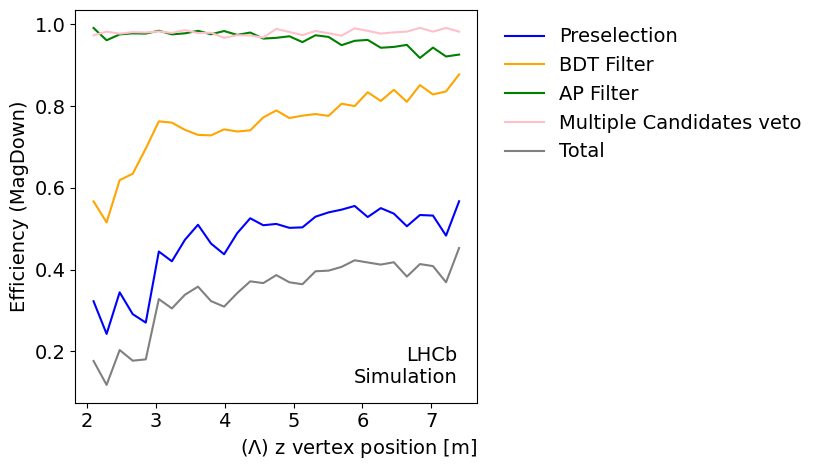

In [6]:
import numpy as np
import matplotlib.pyplot as plt

mc_signal = mc_signal.query('MAGFIELD == False')
mc_signal_preselection = mc_signal_preselection.query('MAGFIELD == False')
mc_signal_BDT = mc_signal_BDT.query('MAGFIELD == False')
mc_signal_AP = mc_signal_AP.query('MAGFIELD == False')
mc_signal_candidates = mc_signal_candidates.query('MAGFIELD == False')

# Crear el gráfico
fig, ax = plt.subplots()

# Definir la variable y los bins
variable = 'p_TRUEORIGIN_VZ'
bins = np.linspace(2000, 7500, 30)
bin_centres = 0.5 * (bins[1:] + bins[:-1]) / 1000  # Convertir a metros

# Calcular histogramas
numerator_hist1, _ = np.histogram(mc_signal_preselection[variable], bins)
denominator_hist1, _ = np.histogram(mc_signal[variable], bins)

numerator_hist2, _ = np.histogram(mc_signal_BDT[variable], bins)
denominator_hist2, _ = np.histogram(mc_signal_preselection[variable], bins)

numerator_hist3, _ = np.histogram(mc_signal_AP[variable], bins)
denominator_hist3, _ = np.histogram(mc_signal_BDT[variable], bins)

numerator_hist4, _ = np.histogram(mc_signal_candidates[variable], bins)
denominator_hist4, _ = np.histogram(mc_signal_AP[variable], bins)

numerator_hist5, _ = np.histogram(mc_signal_candidates[variable], bins)
denominator_hist5, _ = np.histogram(mc_signal[variable], bins)

# Evitar división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio1 = np.divide(numerator_hist1, denominator_hist1, where=denominator_hist1 != 0)
    ratio1_errors = np.sqrt((np.sqrt(numerator_hist1) / numerator_hist1) ** 2 + (np.sqrt(denominator_hist1) / denominator_hist1) ** 2)
    ratio1[denominator_hist1 == 0] = 0
    ratio1_errors[denominator_hist1 == 0] = 0

    ratio2 = np.divide(numerator_hist2, denominator_hist2, where=denominator_hist2 != 0)
    ratio2_errors = np.sqrt((np.sqrt(numerator_hist2) / numerator_hist2) ** 2 + (np.sqrt(denominator_hist2) / denominator_hist2) ** 2)
    ratio2[denominator_hist2 == 0] = 0
    ratio2_errors[denominator_hist2 == 0] = 0

    ratio3 = np.divide(numerator_hist3, denominator_hist3, where=denominator_hist3 != 0)
    ratio3_errors = np.sqrt((np.sqrt(numerator_hist3) / numerator_hist3) ** 2 + (np.sqrt(denominator_hist3) / denominator_hist3) ** 2)
    ratio3[denominator_hist3 == 0] = 0
    ratio3_errors[denominator_hist3 == 0] = 0

    ratio4 = np.divide(numerator_hist4, denominator_hist4, where=denominator_hist4 != 0)
    ratio4_errors = np.sqrt((np.sqrt(numerator_hist4) / numerator_hist4) ** 2 + (np.sqrt(denominator_hist4) / denominator_hist4) ** 2)
    ratio4[denominator_hist4 == 0] = 0
    ratio4_errors[denominator_hist4 == 0] = 0

    ratio5 = np.divide(numerator_hist5, denominator_hist5, where=denominator_hist5 != 0)
    ratio5_errors = np.sqrt((np.sqrt(numerator_hist5) / numerator_hist5) ** 2 + (np.sqrt(denominator_hist5) / denominator_hist5) ** 2)
    ratio5[denominator_hist5 == 0] = 0
    ratio5_errors[denominator_hist5 == 0] = 0

# Graficar líneas
ax.plot(bin_centres, ratio1, label="Preselection", color='blue')
ax.plot(bin_centres, ratio2, label="BDT Filter", color='orange')
ax.plot(bin_centres, ratio3, label="AP Filter", color='green')
ax.plot(bin_centres, ratio4, label="Multiple Candidates veto", color='pink')
ax.plot(bin_centres, ratio5, label="Total", color='grey')

# Añadir texto personalizado
ax.text(0.95, 0.05, "LHCb\nSimulation", transform=ax.transAxes, fontsize=14, color='black', ha='right')

# Ajustes del gráfico
ax.set_xlabel(r'($\Lambda$) z vertex position [m]', fontsize=14, fontname='Times New Roman', loc='right')
ax.set_ylabel('Efficiency (MagDown)', fontsize=14, fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=14)

# Cambiar la fuente predeterminada a Times New Roman para todo el gráfico
plt.rcParams['font.family'] = 'Times New Roman'

# Colocar la leyenda fuera a la derecha del gráfico
legend = ax.legend(fontsize=14, bbox_to_anchor=(1.025, 1), loc='upper left')
legend.get_frame().set_linewidth(0)

# Ajustar el tamaño de la figura para hacer espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1.3, 1])

# Mostrar el gráfico
plt.show()


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

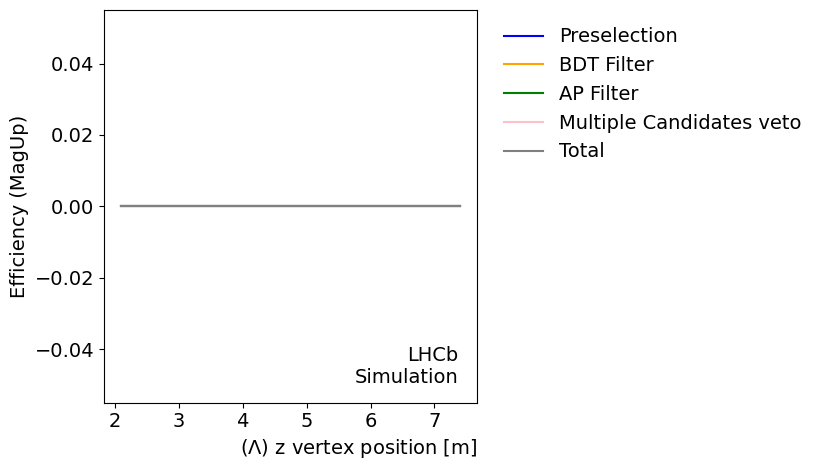

In [7]:
import numpy as np
import matplotlib.pyplot as plt

mc_signal = mc_signal.query('MAGFIELD == True')
mc_signal_preselection = mc_signal_preselection.query('MAGFIELD == True')
mc_signal_BDT = mc_signal_BDT.query('MAGFIELD == True')
mc_signal_AP = mc_signal_AP.query('MAGFIELD == True')
mc_signal_candidates = mc_signal_candidates.query('MAGFIELD == True')

# Crear el gráfico
fig, ax = plt.subplots()

# Definir la variable y los bins
variable = 'p_TRUEORIGIN_VZ'
bins = np.linspace(2000, 7500, 30)
bin_centres = 0.5 * (bins[1:] + bins[:-1]) / 1000  # Convertir a metros

# Calcular histogramas
numerator_hist1, _ = np.histogram(mc_signal_preselection[variable], bins)
denominator_hist1, _ = np.histogram(mc_signal[variable], bins)

numerator_hist2, _ = np.histogram(mc_signal_BDT[variable], bins)
denominator_hist2, _ = np.histogram(mc_signal_preselection[variable], bins)

numerator_hist3, _ = np.histogram(mc_signal_AP[variable], bins)
denominator_hist3, _ = np.histogram(mc_signal_BDT[variable], bins)

numerator_hist4, _ = np.histogram(mc_signal_candidates[variable], bins)
denominator_hist4, _ = np.histogram(mc_signal_AP[variable], bins)

numerator_hist5, _ = np.histogram(mc_signal_candidates[variable], bins)
denominator_hist5, _ = np.histogram(mc_signal[variable], bins)

# Evitar división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio1 = np.divide(numerator_hist1, denominator_hist1, where=denominator_hist1 != 0)
    ratio1_errors = np.sqrt((np.sqrt(numerator_hist1) / numerator_hist1) ** 2 + (np.sqrt(denominator_hist1) / denominator_hist1) ** 2)
    ratio1[denominator_hist1 == 0] = 0
    ratio1_errors[denominator_hist1 == 0] = 0

    ratio2 = np.divide(numerator_hist2, denominator_hist2, where=denominator_hist2 != 0)
    ratio2_errors = np.sqrt((np.sqrt(numerator_hist2) / numerator_hist2) ** 2 + (np.sqrt(denominator_hist2) / denominator_hist2) ** 2)
    ratio2[denominator_hist2 == 0] = 0
    ratio2_errors[denominator_hist2 == 0] = 0

    ratio3 = np.divide(numerator_hist3, denominator_hist3, where=denominator_hist3 != 0)
    ratio3_errors = np.sqrt((np.sqrt(numerator_hist3) / numerator_hist3) ** 2 + (np.sqrt(denominator_hist3) / denominator_hist3) ** 2)
    ratio3[denominator_hist3 == 0] = 0
    ratio3_errors[denominator_hist3 == 0] = 0

    ratio4 = np.divide(numerator_hist4, denominator_hist4, where=denominator_hist4 != 0)
    ratio4_errors = np.sqrt((np.sqrt(numerator_hist4) / numerator_hist4) ** 2 + (np.sqrt(denominator_hist4) / denominator_hist4) ** 2)
    ratio4[denominator_hist4 == 0] = 0
    ratio4_errors[denominator_hist4 == 0] = 0

    ratio5 = np.divide(numerator_hist5, denominator_hist5, where=denominator_hist5 != 0)
    ratio5_errors = np.sqrt((np.sqrt(numerator_hist5) / numerator_hist5) ** 2 + (np.sqrt(denominator_hist5) / denominator_hist5) ** 2)
    ratio5[denominator_hist5 == 0] = 0
    ratio5_errors[denominator_hist5 == 0] = 0

# Graficar líneas
ax.plot(bin_centres, ratio1, label="Preselection", color='blue')
ax.plot(bin_centres, ratio2, label="BDT Filter", color='orange')
ax.plot(bin_centres, ratio3, label="AP Filter", color='green')
ax.plot(bin_centres, ratio4, label="Multiple Candidates veto", color='pink')
ax.plot(bin_centres, ratio5, label="Total", color='grey')

# Añadir texto personalizado
ax.text(0.95, 0.05, "LHCb\nSimulation", transform=ax.transAxes, fontsize=14, color='black', ha='right')

# Ajustes del gráfico
ax.set_xlabel(r'($\Lambda$) z vertex position [m]', fontsize=14, fontname='Times New Roman', loc='right')
ax.set_ylabel('Efficiency (MagUp)', fontsize=14, fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=14)

# Cambiar la fuente predeterminada a Times New Roman para todo el gráfico
plt.rcParams['font.family'] = 'Times New Roman'

# Colocar la leyenda fuera a la derecha del gráfico
legend = ax.legend(fontsize=14, bbox_to_anchor=(1.025, 1), loc='upper left')
legend.get_frame().set_linewidth(0)

# Ajustar el tamaño de la figura para hacer espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1.3, 1])

# Mostrar el gráfico
plt.show()


Código viejo de aumento de eficiencia para la preselección 

In [19]:
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '

In [20]:
cut_1 = '(Jpsi_P > 10000)'
cut_2 = '(mup_PID_MU > 0)'
cut_3 = '(mum_PID_MU > 0)'
cut_4 = '(Jpsi_MAXDOCA < 0.15)'
cut_5 = '(p_PID_P > 0)'
cut_6 = '(p_P > 10000)'
cut_7 = '(p_PT > 400)'
cut_8 = '(pim_P > 2000)'
cut_9 = '(L_PT > 450)'
cut_10 = '(Lb_CHI2 < 150)'
cut_11 = '(L_MASS < 1800) & (L_MASS > 950)'
cut_12 = '(Jpsi_CHI2 < 4 )'
cut_13 = '(L_CHI2 < 100)'


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

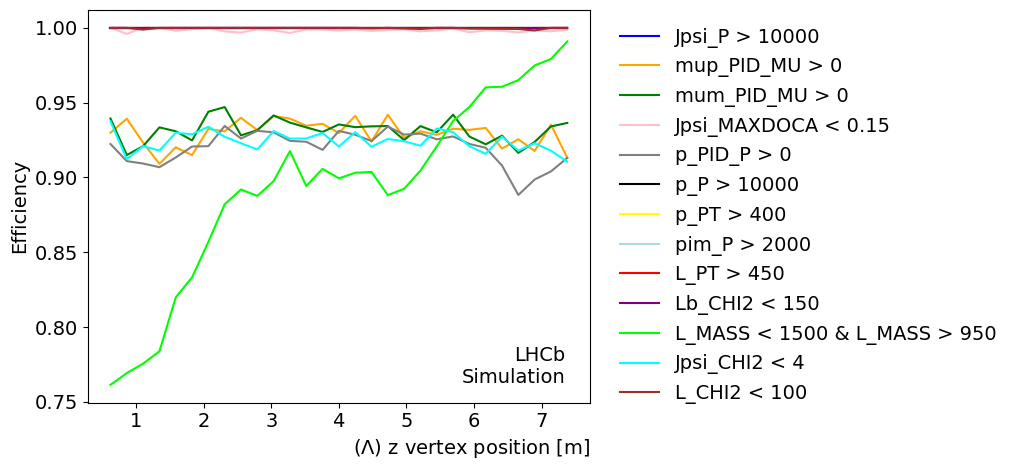

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# # Filtrar datos según los criterios especificados
# mc_signal_BDT = mc_signal_preselection.query('(prob1) > 0.95')
# mc_signal_AP = mc_signal_BDT.loc[(abs(mc_signal_preselection['alpha_combined']) > 0.45)]

# Crear el gráfico
fig, ax = plt.subplots()

# Definir la variable y los bins
variable = 'p_TRUEORIGIN_VZ'
bins = np.linspace(500, 7500, 30)
bin_centres = 0.5 * (bins[1:] + bins[:-1]) / 1000  # Convertir a metros

# Calcular histogramas
numerator_hist1, _ = np.histogram(mc_signal.query(cut_1)[variable], bins)
denominator_hist1, _ = np.histogram(mc_signal[variable], bins)

numerator_hist2, _ = np.histogram(mc_signal.query(cut_2)[variable], bins)
denominator_hist2, _ = np.histogram(mc_signal[variable], bins)

numerator_hist3, _ = np.histogram(mc_signal.query(cut_3)[variable], bins)
denominator_hist3, _ =np.histogram(mc_signal[variable], bins)

numerator_hist4, _ = np.histogram(mc_signal.query(cut_4)[variable], bins)
denominator_hist4, _ = np.histogram(mc_signal[variable], bins)

numerator_hist5, _ = np.histogram(mc_signal.query(cut_5)[variable], bins)
denominator_hist5, _ = np.histogram(mc_signal[variable], bins)

numerator_hist6, _ = np.histogram(mc_signal.query(cut_6)[variable], bins)
denominator_hist6, _ = np.histogram(mc_signal[variable], bins)

numerator_hist7, _ = np.histogram(mc_signal.query(cut_7)[variable], bins)
denominator_hist7, _ = np.histogram(mc_signal[variable], bins)

numerator_hist8, _ = np.histogram(mc_signal.query(cut_8)[variable], bins)
denominator_hist8, _ = np.histogram(mc_signal[variable], bins)

numerator_hist9, _ = np.histogram(mc_signal.query(cut_9)[variable], bins)
denominator_hist9, _ = np.histogram(mc_signal[variable], bins)

numerator_hist10, _ = np.histogram(mc_signal.query(cut_10)[variable], bins)
denominator_hist10, _ = np.histogram(mc_signal[variable], bins)

numerator_hist11, _ = np.histogram(mc_signal.query(cut_11)[variable], bins)
denominator_hist11, _ = np.histogram(mc_signal[variable], bins)

numerator_hist12, _ = np.histogram(mc_signal.query(cut_12)[variable], bins)
denominator_hist12, _ =np.histogram(mc_signal[variable], bins)

numerator_hist13, _ = np.histogram(mc_signal.query(cut_13)[variable], bins)
denominator_hist13, _ = np.histogram(mc_signal[variable], bins)

# Evitar división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio1 = np.divide(numerator_hist1, denominator_hist1, where=denominator_hist1 != 0)
    ratio1_errors = np.sqrt((np.sqrt(numerator_hist1) / numerator_hist1) ** 2 + (np.sqrt(denominator_hist1) / denominator_hist1) ** 2)
    ratio1[denominator_hist1 == 0] = 0
    ratio1_errors[denominator_hist1 == 0] = 0

    ratio2 = np.divide(numerator_hist2, denominator_hist2, where=denominator_hist2 != 0)
    ratio2_errors = np.sqrt((np.sqrt(numerator_hist2) / numerator_hist2) ** 2 + (np.sqrt(denominator_hist2) / denominator_hist2) ** 2)
    ratio2[denominator_hist2 == 0] = 0
    ratio2_errors[denominator_hist2 == 0] = 0

    ratio3 = np.divide(numerator_hist3, denominator_hist3, where=denominator_hist3 != 0)
    ratio3_errors = np.sqrt((np.sqrt(numerator_hist3) / numerator_hist3) ** 2 + (np.sqrt(denominator_hist3) / denominator_hist3) ** 2)
    ratio3[denominator_hist3 == 0] = 0
    ratio3_errors[denominator_hist3 == 0] = 0

    ratio4 = np.divide(numerator_hist4, denominator_hist4, where=denominator_hist4 != 0)
    ratio4_errors = np.sqrt((np.sqrt(numerator_hist4) / numerator_hist4) ** 2 + (np.sqrt(denominator_hist4) / denominator_hist4) ** 2)
    ratio4[denominator_hist4 == 0] = 0
    ratio4_errors[denominator_hist4 == 0] = 0

    ratio5 = np.divide(numerator_hist5, denominator_hist5, where=denominator_hist5 != 0)
    ratio5_errors = np.sqrt((np.sqrt(numerator_hist5) / numerator_hist5) ** 2 + (np.sqrt(denominator_hist5) / denominator_hist5) ** 2)
    ratio5[denominator_hist5 == 0] = 0
    ratio5_errors[denominator_hist5 == 0] = 0
    
    ratio6 = np.divide(numerator_hist6, denominator_hist6, where=denominator_hist6 != 0)
    ratio6_errors = np.sqrt((np.sqrt(numerator_hist6) / numerator_hist6) ** 2 + (np.sqrt(denominator_hist6) / denominator_hist6) ** 2)
    ratio6[denominator_hist6 == 0] = 0
    ratio6_errors[denominator_hist6 == 0] = 0

    ratio7 = np.divide(numerator_hist7, denominator_hist7, where=denominator_hist7 != 0)
    ratio7_errors = np.sqrt((np.sqrt(numerator_hist7) / numerator_hist7) ** 2 + (np.sqrt(denominator_hist7) / denominator_hist7) ** 2)
    ratio7[denominator_hist7 == 0] = 0
    ratio7_errors[denominator_hist7 == 0] = 0

    ratio8 = np.divide(numerator_hist8, denominator_hist8, where=denominator_hist8 != 0)
    ratio8_errors = np.sqrt((np.sqrt(numerator_hist8) / numerator_hist8) ** 2 + (np.sqrt(denominator_hist8) / denominator_hist8) ** 2)
    ratio8[denominator_hist8 == 0] = 0
    ratio8_errors[denominator_hist8 == 0] = 0

    ratio9 = np.divide(numerator_hist9, denominator_hist9, where=denominator_hist9 != 0)
    ratio9_errors = np.sqrt((np.sqrt(numerator_hist9) / numerator_hist9) ** 2 + (np.sqrt(denominator_hist9) / denominator_hist9) ** 2)
    ratio9[denominator_hist9 == 0] = 0
    ratio9_errors[denominator_hist9 == 0] = 0

    ratio10 = np.divide(numerator_hist10, denominator_hist10, where=denominator_hist10 != 0)
    ratio10_errors = np.sqrt((np.sqrt(numerator_hist10) / numerator_hist10) ** 2 + (np.sqrt(denominator_hist10) / denominator_hist10) ** 2)
    ratio10[denominator_hist10 == 0] = 0
    ratio10_errors[denominator_hist10 == 0] = 0

    ratio11 = np.divide(numerator_hist11, denominator_hist11, where=denominator_hist11 != 0)
    ratio11_errors = np.sqrt((np.sqrt(numerator_hist11) / numerator_hist11) ** 2 + (np.sqrt(denominator_hist11) / denominator_hist11) ** 2)
    ratio11[denominator_hist11 == 0] = 0
    ratio11_errors[denominator_hist11 == 0] = 0

    ratio12 = np.divide(numerator_hist12, denominator_hist12, where=denominator_hist12 != 0)
    ratio12_errors = np.sqrt((np.sqrt(numerator_hist12) / numerator_hist12) ** 2 + (np.sqrt(denominator_hist12) / denominator_hist12) ** 2)
    ratio12[denominator_hist12 == 0] = 0
    ratio12_errors[denominator_hist12 == 0] = 0

    ratio13 = np.divide(numerator_hist13, denominator_hist13, where=denominator_hist13 != 0)
    ratio13_errors = np.sqrt((np.sqrt(numerator_hist13) / numerator_hist13) ** 2 + (np.sqrt(denominator_hist13) / denominator_hist13) ** 2)
    ratio13[denominator_hist13 == 0] = 0
    ratio13_errors[denominator_hist13 == 0] = 0

# Graficar líneas
ax.plot(bin_centres, ratio1, label="Jpsi_P > 10000", color='blue')
ax.plot(bin_centres, ratio2, label="mup_PID_MU > 0", color='orange')
ax.plot(bin_centres, ratio3, label="mum_PID_MU > 0", color='green')
ax.plot(bin_centres, ratio4, label="Jpsi_MAXDOCA < 0.15", color='pink')
ax.plot(bin_centres, ratio5, label="p_PID_P > 0", color='grey')
ax.plot(bin_centres, ratio6, label="p_P > 10000", color='black')
ax.plot(bin_centres, ratio7, label="p_PT > 400", color='yellow')
ax.plot(bin_centres, ratio8, label="pim_P > 2000", color='lightblue')
ax.plot(bin_centres, ratio9, label="L_PT > 450", color='red')
ax.plot(bin_centres, ratio10, label="Lb_CHI2 < 150", color='purple')
ax.plot(bin_centres, ratio11, label="L_MASS < 1500 & L_MASS > 950", color='lime')
ax.plot(bin_centres, ratio12, label="Jpsi_CHI2 < 4", color='aqua')
ax.plot(bin_centres, ratio13, label="L_CHI2 < 100", color='brown')


# Añadir texto personalizado
ax.text(0.95, 0.05, "LHCb\nSimulation", transform=ax.transAxes, fontsize=14, color='black', ha='right')

# Ajustes del gráfico
ax.set_xlabel(r'($\Lambda$) z vertex position [m]', fontsize=14, fontname='Times New Roman', loc='right')
ax.set_ylabel('Efficiency', fontsize=14, fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=14)

# Cambiar la fuente predeterminada a Times New Roman para todo el gráfico
plt.rcParams['font.family'] = 'Times New Roman'

# Colocar la leyenda fuera a la derecha del gráfico
legend = ax.legend(fontsize=14, bbox_to_anchor=(1.025, 1), loc='upper left')
legend.get_frame().set_linewidth(0)

# Ajustar el tamaño de la figura para hacer espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1.6, 1])

# Mostrar el gráfico
plt.show()


In [22]:
print(np.mean(ratio1))
print(np.mean(ratio2))
print(np.mean(ratio3))
print(np.mean(ratio4))
print(np.mean(ratio5))
print(np.mean(ratio6))
print(np.mean(ratio7))
print(np.mean(ratio8))
print(np.mean(ratio9))
print(np.mean(ratio10))
print(np.mean(ratio11))
print(np.mean(ratio12))
print(np.mean(ratio13))


1.0
0.9294177904845605
0.9315289144037465
0.9983542547127705
0.9198646698914502
1.0
1.0
1.0
1.0
1.0
0.8932691075347138
0.9241960083422547
0.999762539761441


In [23]:
print(np.mean(ratio11))

0.8932691075347138
